# Netflix Movies and TV Shows Analysis
This project explores the Netflix dataset to identify trends in movies and TV shows available on the platform.  
The analysis focuses on content distribution, production countries, genres, and release trends over time.

## Project Objectives

The main objectives of this analysis are:

- Understand the distribution of Movies and TV Shows on Netflix
- Identify the countries producing the most content
- Analyze the growth of Netflix content over time
- Explore the most common genres available on the platform
- Extract insights from the dataset through data visualization

## Importing Required Libraries

In [190]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

## Loading the Dataset

In [151]:
df=pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Exploratory Data Analysis (EDA)
Before performing any analysis, it is important to explore the dataset in order to understand its structure, identify missing values, and examine the available variables.

In [152]:
df.shape

(8807, 12)

In [153]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [154]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [156]:
df[df.duplicated()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


## Outlier Detection and Analysis

To identify potential outliers in the dataset, the Interquartile Range (IQR) method was applied to the `release_year` variable.

The calculated bounds were:
- Lower bound: 2004
- Upper bound: 2028

According to this method, any movie released before 2004 is considered a statistical outlier.

However, after further analysis, it was observed that a large number of titles fall below this threshold. These entries correspond to older movies and classic content available on Netflix.

Therefore, these values are not considered data errors but rather valid observations representing older productions.



In [157]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [158]:
Q1 = df['release_year'].quantile(0.25)
Q3 = df['release_year'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)

2004.0 2028.0


In [159]:
df[df['release_year'] < 2004]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
22,s23,Movie,Avvai Shanmughi,K.S. Ravikumar,"Kamal Hassan, Meena, Gemini Ganesan, Heera Raj...",NaN,"September 21, 2021",1996,TV-PG,161 min,"Comedies, International Movies",Newly divorced and denied visitation rights wi...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
26,s27,Movie,Minsara Kanavu,Rajiv Menon,"Arvind Swamy, Kajol, Prabhu Deva, Nassar, S.P....",NaN,"September 21, 2021",1997,TV-PG,147 min,"Comedies, International Movies, Music & Musicals",A tangled love triangle ensues when a man fall...
41,s42,Movie,Jaws,Steven Spielberg,"Roy Scheider, Robert Shaw, Richard Dreyfuss, L...",United States,"September 16, 2021",1975,PG,124 min,"Action & Adventure, Classic Movies, Dramas",When an insatiable great white shark terrorize...
...,...,...,...,...,...,...,...,...,...,...,...,...
8764,s8765,Movie,Wyatt Earp,Lawrence Kasdan,"Kevin Costner, Dennis Quaid, Gene Hackman, Dav...",United States,"January 1, 2020",1994,PG-13,191 min,Action & Adventure,Legendary lawman Wyatt Earp is continually at ...
8766,s8767,Movie,XXx,Rob Cohen,"Vin Diesel, Asia Argento, Marton Csokas, Samue...",United States,"January 1, 2019",2002,PG-13,124 min,"Action & Adventure, Sports Movies",A notorious underground rush-seeker deemed unt...
8768,s8769,Movie,Y Tu Mamá También,Alfonso Cuarón,"Maribel Verdú, Gael García Bernal, Diego Luna,...",Mexico,"June 1, 2017",2001,R,106 min,"Dramas, Independent Movies, International Movies",When rich teens Tenoch and Julio meet the allu...
8770,s8771,Movie,Yaadein,Subhash Ghai,"Jackie Shroff, Hrithik Roshan, Kareena Kapoor,...",India,"March 1, 2018",2001,TV-14,171 min,"Dramas, International Movies, Romantic Movies",Two young lovers set out to overcome the obsta...


<Axes: >

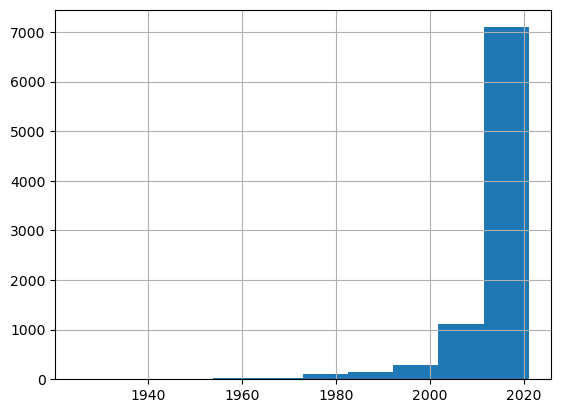

In [160]:
df['release_year'].hist()

In [161]:
df['era'] = df['release_year'].apply(lambda x: "Old" if x < 2004 else "Recent")

In [162]:
df['era'].value_counts()

era
Recent    8088
Old        719
Name: count, dtype: int64

### Percentage of Missing Values by Column

This bar chart shows the proportion of missing values for each column in the dataset relative to the total number of entries.  

It provides a clear overview of which columns have significant missing data and helps determine which columns require cleaning or special attention.  

Columns like `director` show a high percentage of missing values, while `date_added`, `rating`, and `duration` have very few missing values.  

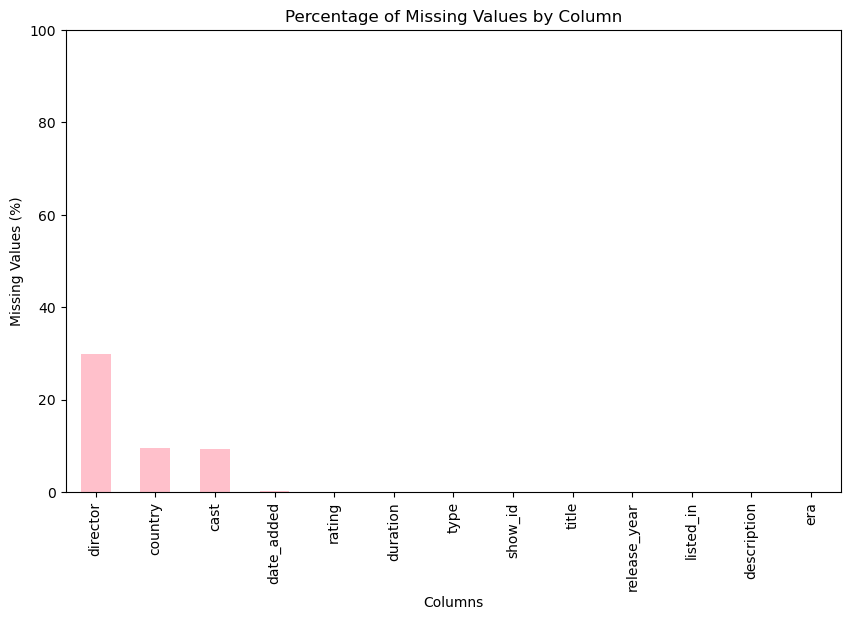

In [163]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent = missing_percent.sort_values(ascending=False)

plt.figure(figsize=(10,6))
missing_percent.plot(kind='bar', color='pink')
plt.title("Percentage of Missing Values by Column")
plt.ylabel("Missing Values (%)")
plt.xlabel("Columns")
plt.ylim(0, 100)  
plt.show()

### Missing Values by Column

This bar chart shows the total number of missing values for each column in the dataset. It helps identify which columns need cleaning or special attention.

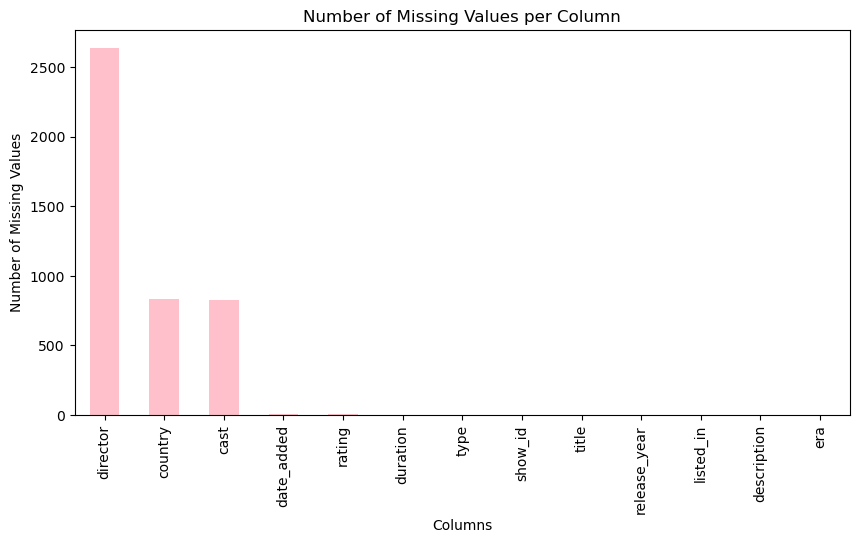

In [164]:
plt.figure(figsize=(10,5))
df.isnull().sum().sort_values(ascending=False).plot(kind='bar', color='pink')
plt.title("Number of Missing Values per Column")
plt.ylabel("Number of Missing Values")
plt.xlabel("Columns")
plt.show()

### Missing Values Heatmap

The heatmap visualizes missing values across all rows and columns.  
It helps detect patterns and relationships between missing data.

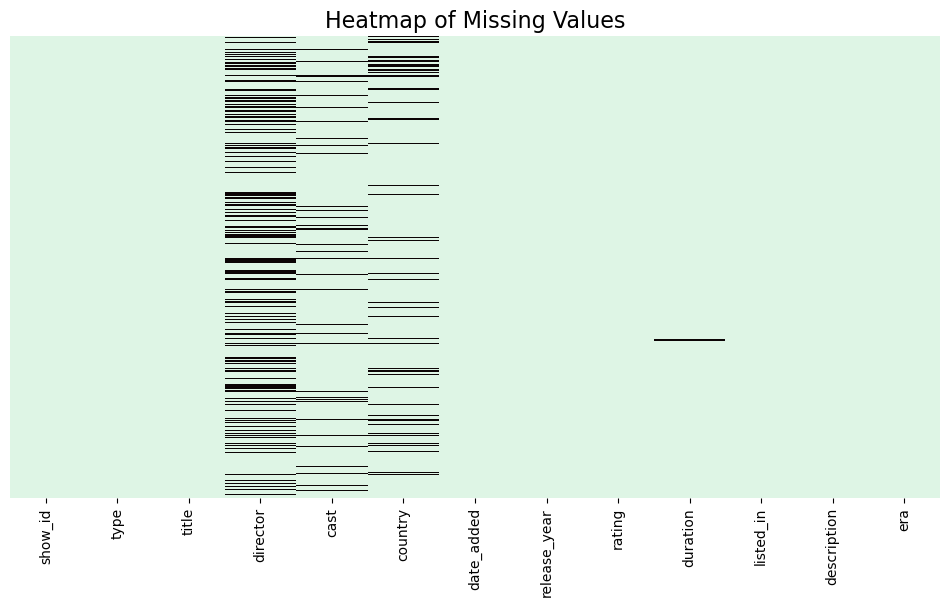

In [165]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap=sns.color_palette("mako_r", as_cmap=True), yticklabels=False)
plt.title("Heatmap of Missing Values", fontsize=16)
plt.show()

### Missing Values Matrix

This matrix shows the presence and absence of data for all columns, highlighting correlations between missing values.

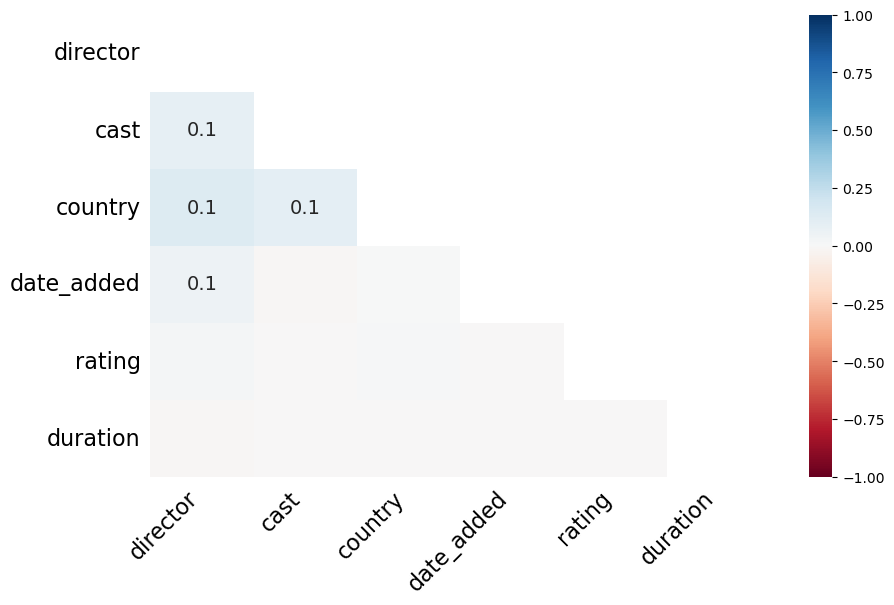

In [166]:
msno.heatmap(df, figsize=(10,6))
plt.show()

### Cleaning Director Column

We created a cleaned version of the `director` column to handle missing values.  
Missing values (`NaN`) are replaced with `"Unknown"` in a new column `director_clean` so that we can perform analyses without losing data.  
The original `director` column is kept intact to preserve raw information.

In [167]:
df['director'] = df['director'].replace('', pd.NA)

df['director_clean'] = df['director'].fillna('Unknown')

df[['director', 'director_clean']].head(10)


,director,director_clean
0,Kirsten Johnson,Kirsten Johnson
1,NaN,Unknown
2,Julien Leclercq,Julien Leclercq
3,NaN,Unknown
4,NaN,Unknown
5,Mike Flanagan,Mike Flanagan
6,"Robert Cullen, José Luis Ucha","Robert Cullen, José Luis Ucha"
7,Haile Gerima,Haile Gerima
8,Andy Devonshire,Andy Devonshire
9,Theodore Melfi,Theodore Melfi


In [168]:
df['director_clean'].isnull().sum()

np.int64(0)

### Cleaning Cast Column

Similar to directors, we handle missing values in the `cast` column by creating `cast_clean`.  
`NaN` values are replaced with `"Unknown"` to allow proper analysis of actors without removing rows.  
Original `cast` column remains untouched for reference.



In [169]:
df['cast'] = df['cast'].replace('', pd.NA)
df['cast_clean'] = df['cast'].fillna('Unknown')
df[['cast','cast_clean']].head(10)

,cast,cast_clean
0,NaN,Unknown
1,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...","Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban..."
2,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...","Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi..."
3,NaN,Unknown
4,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...","Mayur More, Jitendra Kumar, Ranjan Raj, Alam K..."
5,"Kate Siegel, Zach Gilford, Hamish Linklater, H...","Kate Siegel, Zach Gilford, Hamish Linklater, H..."
6,"Vanessa Hudgens, Kimiko Glenn, James Marsden, ...","Vanessa Hudgens, Kimiko Glenn, James Marsden, ..."
7,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D..."
8,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...","Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho..."
9,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...","Melissa McCarthy, Chris O'Dowd, Kevin Kline, T..."


In [170]:
df['cast_clean'].isnull().sum()

np.int64(0)

### Cleaning Country Column

For the `country` column, missing values are replaced in a new column `country_clean`.  
This ensures we can analyze content distribution by country without losing any entries.  
Original `country` column is preserved for raw data reference.


In [171]:
df['country_clean'] = df['country'].fillna('Unkown')
df[['country','country_clean']].head(10)

,country,country_clean
0,United States,United States
1,South Africa,South Africa
2,NaN,Unkown
3,NaN,Unkown
4,India,India
5,NaN,Unkown
6,NaN,Unkown
7,"United States, Ghana, Burkina Faso, United Kin...","United States, Ghana, Burkina Faso, United Kin..."
8,United Kingdom,United Kingdom
9,United States,United States


In [172]:
df['country_clean'].isnull().sum()

np.int64(0)

### General Analysis: Movies vs TV Shows

First, we will analyze the distribution of Movies and TV Shows on Netflix to understand the dominant type of content.

In [173]:
df['type'].unique()

array(['Movie', 'TV Show'], dtype=object)

In [174]:
type_counts = df['type'].value_counts()
print(type_counts)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


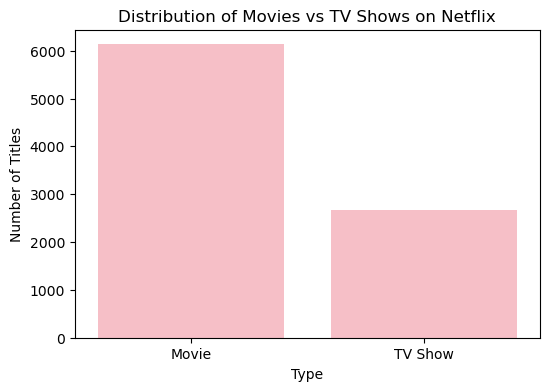

In [175]:
plt.figure(figsize=(6,4))
sns.barplot(x=type_counts.index, y=type_counts.values, color="lightpink") 
plt.title("Distribution of Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Number of Titles")
plt.show()

### Analysis by Country

Next, we will look at which countries produce the most content on Netflix to identify the main contributors.

In [176]:
top_country = df['country_clean'].value_counts().head(10)
print(top_country)

country_clean
United States     2818
India              972
Unkown             831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


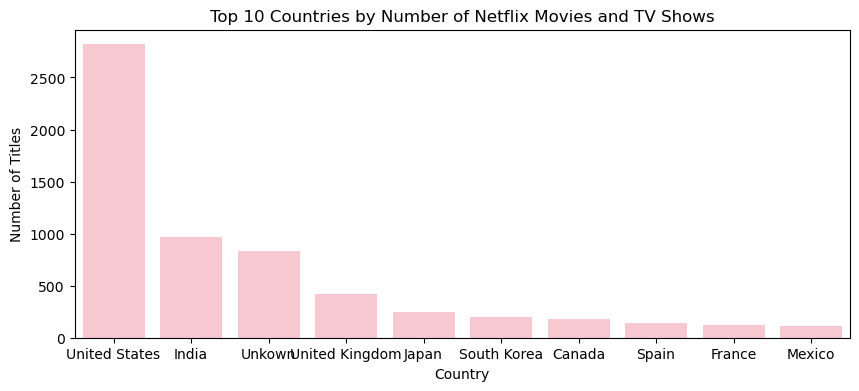

In [177]:
plt.figure(figsize=(10,4))
sns.barplot(y=top_country.values, x=top_country.index , color="pink")
plt.title("Top 10 Countries by Number of Netflix Movies and TV Shows")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

### Growth of Netflix Content Over Time

We will analyze the number of Movies and TV Shows released on Netflix each year to understand content growth trends on the platform.

In [178]:
counts_per_year =df['release_year'].value_counts()

In [179]:
counts_per_year = counts_per_year.sort_index()
print(counts_per_year)

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64


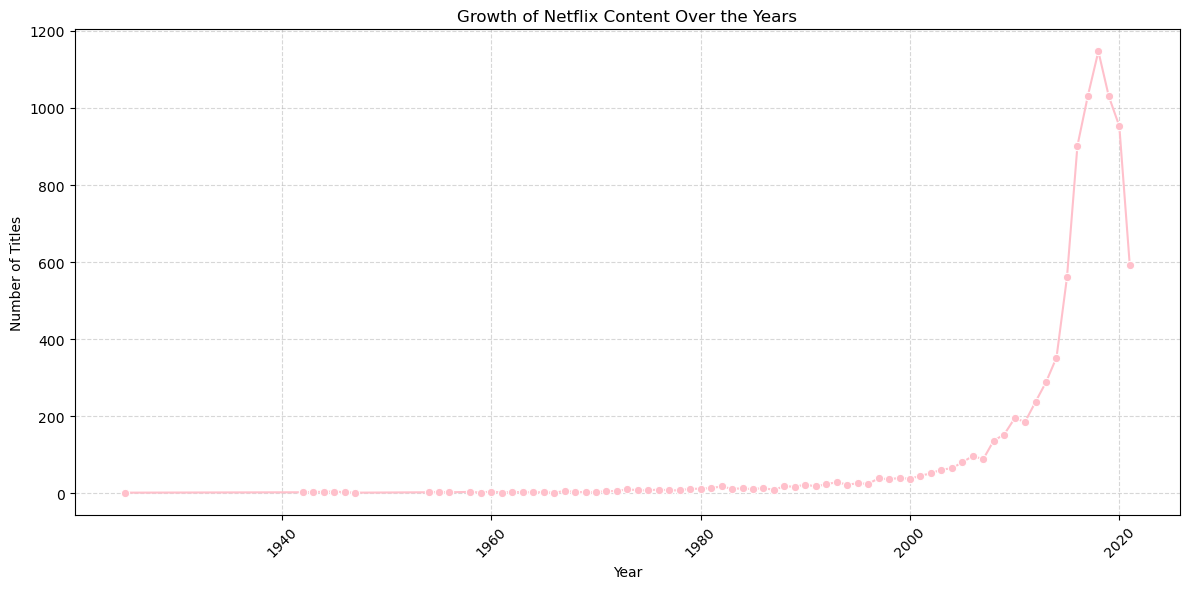

In [180]:
plt.figure(figsize=(12,6))
sns.lineplot(x=counts_per_year.index, y=counts_per_year.values, color="pink", marker="o")

# améliorer les ticks pour lisibilité
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.title("Growth of Netflix Content Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

### Analysis of Netflix Genres

Next, we will explore the most common genres available on Netflix to understand what type of content dominates the platform.

In [191]:
df_genre_country = df[['listed_in', 'country']].copy()
df_genre_country['listed_in'] = df_genre_country['listed_in'].str.strip().str.replace('"', '')

print(df_genre_country['listed_in'].unique())

genre_country_ct = pd.crosstab(df_genre_country['listed_in'], df_genre_country['country'])


['Documentaries' 'International TV Shows, TV Dramas, TV Mysteries'
 'Crime TV Shows, International TV Shows, TV Action & Adventure'
 'Docuseries, Reality TV'
 'International TV Shows, Romantic TV Shows, TV Comedies'
 'TV Dramas, TV Horror, TV Mysteries' 'Children & Family Movies'
 'Dramas, Independent Movies, International Movies'
 'British TV Shows, Reality TV' 'Comedies, Dramas'
 'Crime TV Shows, Docuseries, International TV Shows'
 'Dramas, International Movies' 'Children & Family Movies, Comedies'
 'British TV Shows, Crime TV Shows, Docuseries' 'TV Comedies, TV Dramas'
 'Documentaries, International Movies'
 'Crime TV Shows, Spanish-Language TV Shows, TV Dramas' 'Thrillers'
 'International TV Shows, Spanish-Language TV Shows, TV Action & Adventure'
 'International TV Shows, TV Action & Adventure, TV Dramas'
 'Comedies, International Movies'
 'Comedies, International Movies, Romantic Movies'
 'Docuseries, International TV Shows, Reality TV'
 'Comedies, International Movies, Music & 

In [192]:
genres_exp = df['listed_in'].dropna().astype(str).str.split(',')

genres_exp = genres_exp.explode()

genres_exp = genres_exp.str.strip().str.replace(r"[\[\]'\"\n]", "", regex=True)

top_genres_indiv = genres_exp.value_counts()

print(top_genres_indiv.head(42)) 

listed_in
International Movies            2752
Dramas                          2427
Comedies                        1674
International TV Shows          1351
Documentaries                    869
Action & Adventure               859
TV Dramas                        763
Independent Movies               756
Children & Family Movies         641
Romantic Movies                  616
TV Comedies                      581
Thrillers                        577
Crime TV Shows                   470
Kids TV                          451
Docuseries                       395
Music & Musicals                 375
Romantic TV Shows                370
Horror Movies                    357
Stand-Up Comedy                  343
Reality TV                       255
British TV Shows                 253
Sci-Fi & Fantasy                 243
Sports Movies                    219
Anime Series                     176
Spanish-Language TV Shows        174
TV Action & Adventure            168
Korean TV Shows             

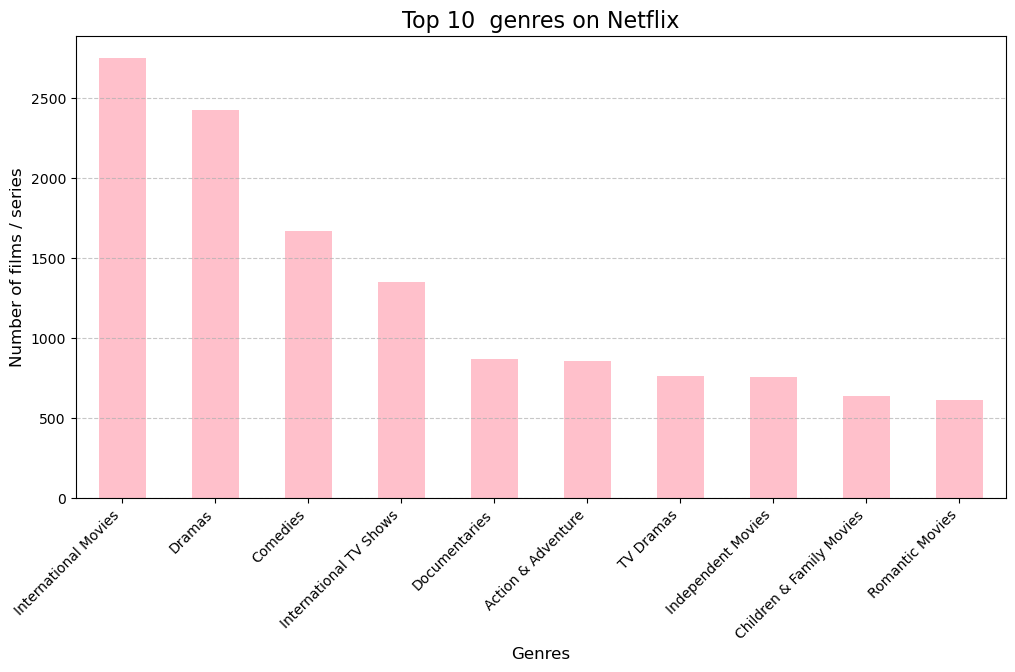

In [225]:

top_genres_indiv = genres_exp.value_counts().head(10)

plt.figure(figsize=(12,6))
top_genres_indiv.plot(kind='bar', color='pink')
plt.title("Top 10  genres on Netflix", fontsize=16)
plt.xlabel("Genres", fontsize=12)
plt.ylabel("Number of films / series", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In order to better understand the diversity of the Netflix catalog, we identify the least represented genres in the dataset. Detecting these categories helps highlight potential content gaps where Netflix could expand its offerings.


In [194]:
underrepresented_genres = top_genres_indiv.tail(5)

print("Underrepresented genres:")
print(underrepresented_genres)

Underrepresented genres:
listed_in
Action & Adventure          859
TV Dramas                   763
Independent Movies          756
Children & Family Movies    641
Romantic Movies             616
Name: count, dtype: int64


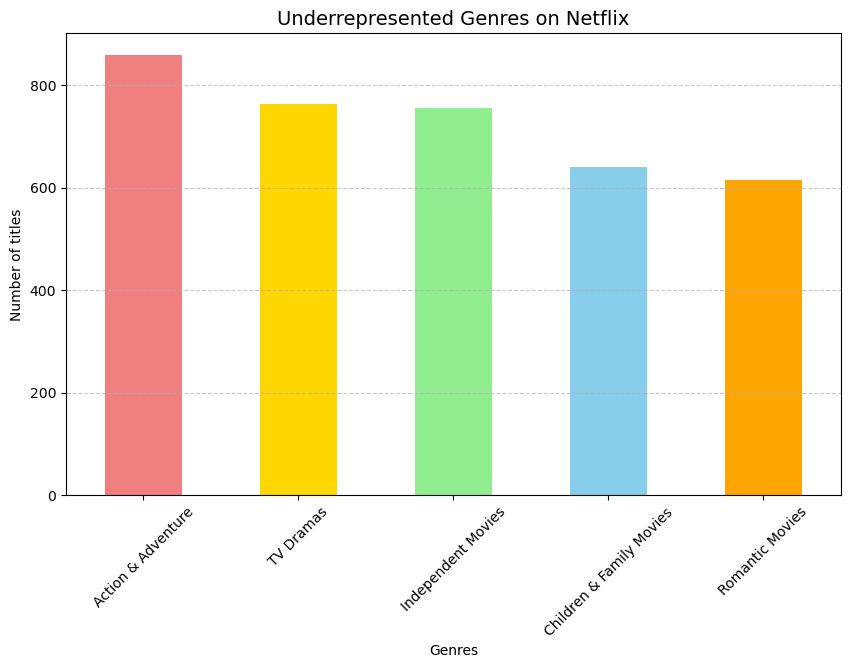

In [226]:
plt.figure(figsize=(10,6))

underrepresented_genres.plot(
    kind='bar',
    color=['lightcoral','gold','lightgreen','skyblue','orange']
)

plt.title("Underrepresented Genres on Netflix", fontsize=14)
plt.xlabel("Genres")
plt.ylabel("Number of titles")
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Analysis of Netflix Genres vs Type

Next, we explore how the most common genres are distributed across Movies and TV Shows on Netflix.

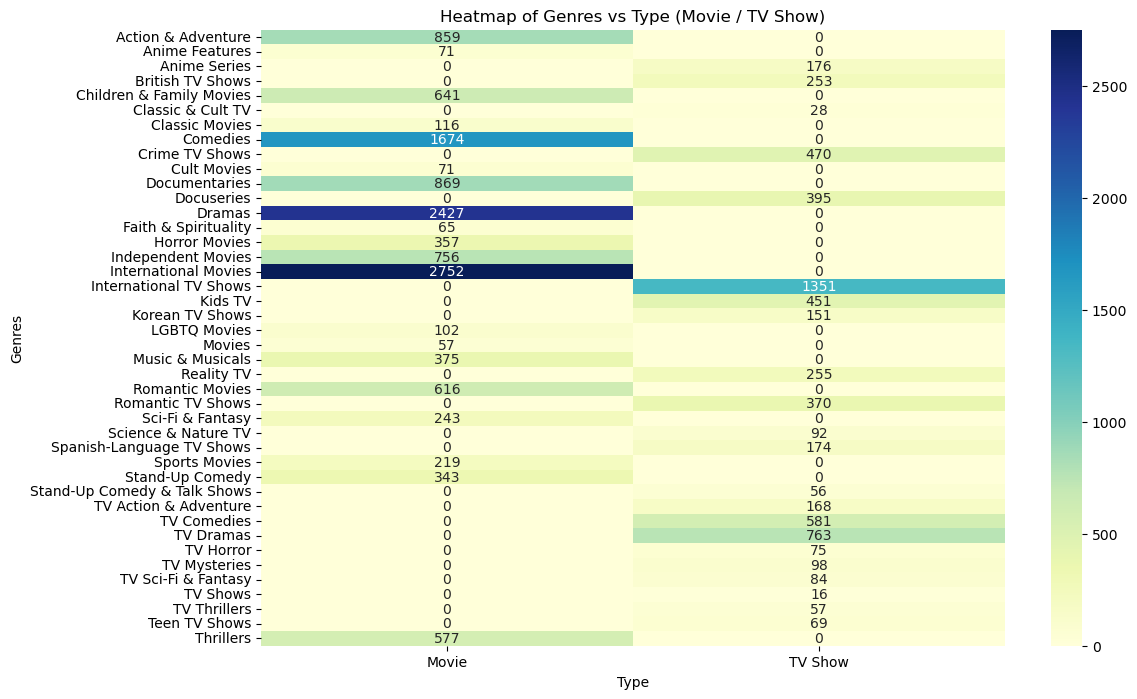

In [218]:
df_genre_type = df[['listed_in', 'type']].dropna(subset=['listed_in', 'type']).copy()
df_genre_type['listed_in'] = df_genre_type['listed_in'].astype(str).str.split(',')
df_genre_type = df_genre_type.explode('listed_in')

df_genre_type['listed_in'] = (
    df_genre_type['listed_in']
    .astype(str)
    .str.replace(r"[\[\]'\"\"]", "", regex=True)
    .str.strip()
)

genre_type_ct = pd.crosstab(df_genre_type['listed_in'], df_genre_type['type'])

plt.figure(figsize=(12,8))
sns.heatmap(genre_type_ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Heatmap of Genres vs Type (Movie / TV Show)")
plt.ylabel("Genres")
plt.xlabel("Type")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()

## Analysis of Netflix Genres vs Country

In this section, we examine how different genres are distributed across countries on Netflix. 

We focus on the top 10 countries with the most content to better understand which types of content are produced predominantly by each country. A heatmap is used to visualize these patterns clearly.

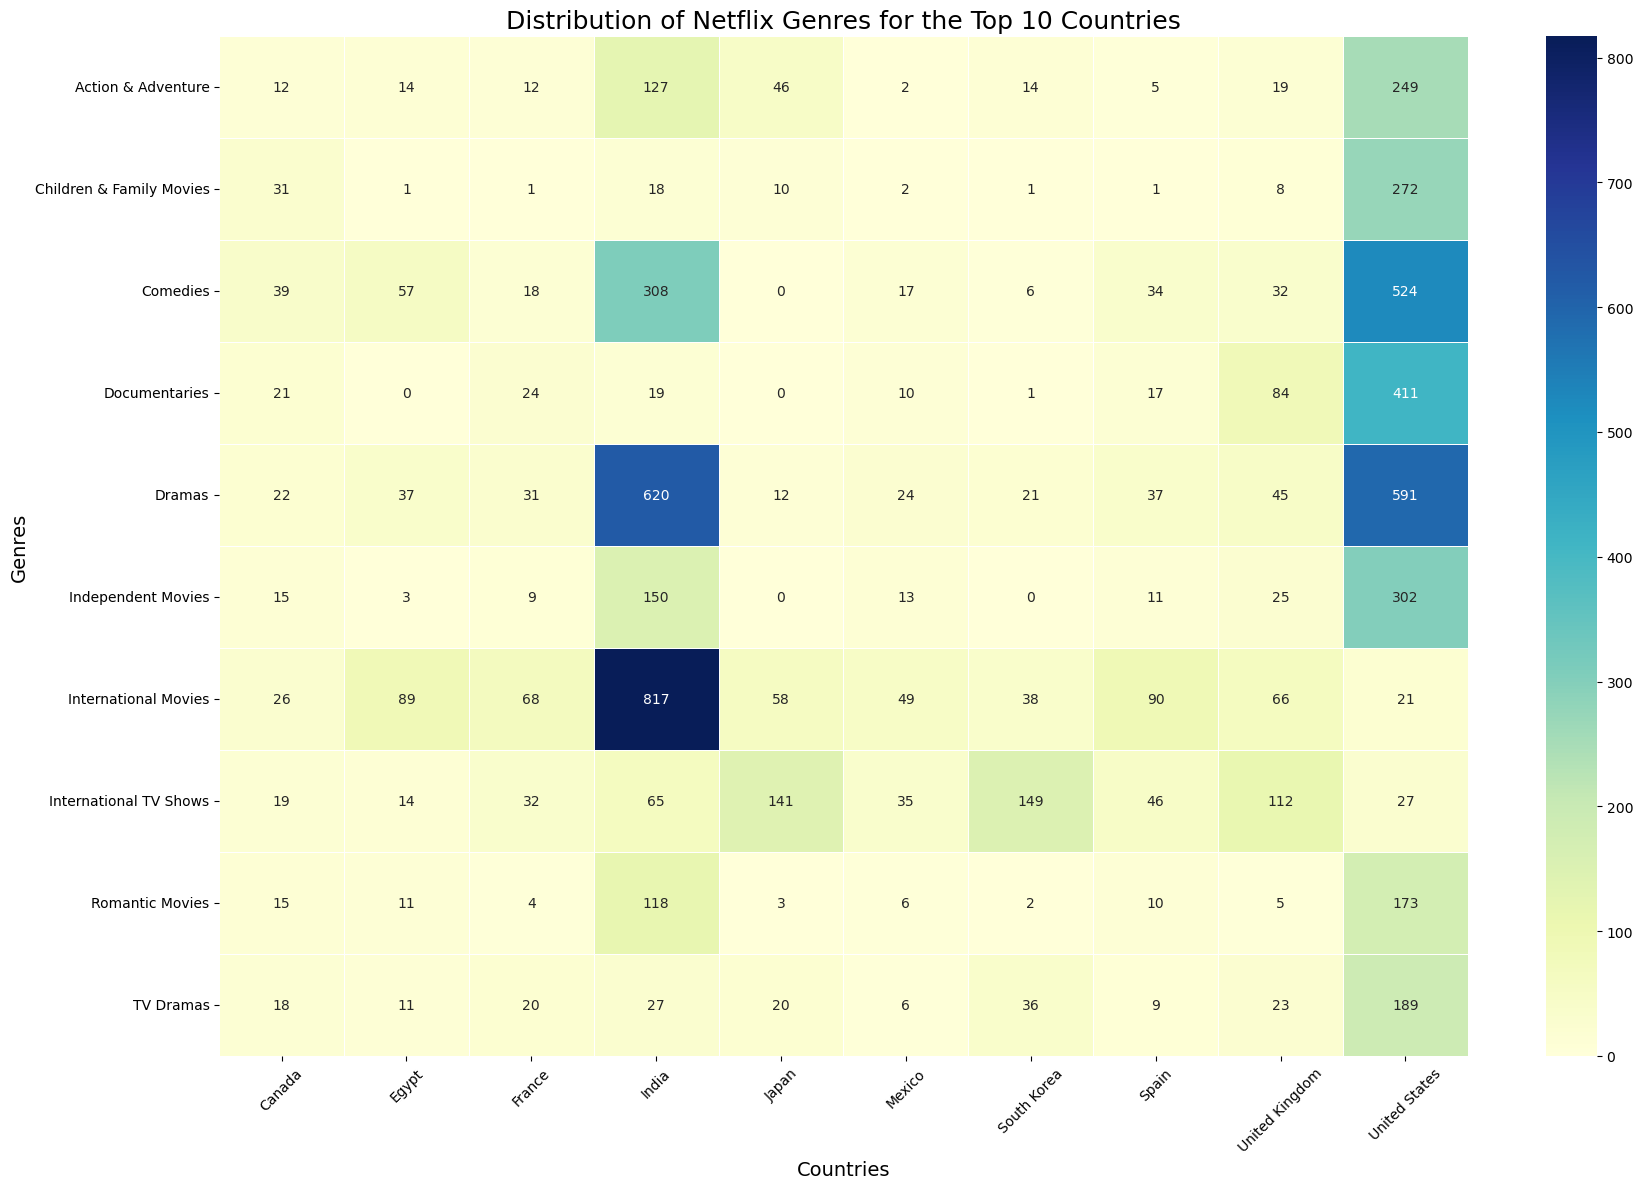

In [224]:
def explode_genres(df):
    data_exploded = []
    
    for country in df.columns:
        for genre_combo in df.index:
            count = df.loc[genre_combo, country]
            if count > 0: 
               
                individual_genres = [g.strip() for g in genre_combo.split(',')]
                for genre in individual_genres:
                    data_exploded.append({
                        'country': country,
                        'genre': genre,
                        'count': count
                    })
    
    df_exploded = pd.DataFrame(data_exploded)
    
    return df_exploded.pivot_table(
        index='genre', 
        columns='country', 
        values='count', 
        aggfunc='sum', 
        fill_value=0
    )

genre_top10_individual = explode_genres(genre_top10)

top_genres_list = top_genres_indiv.head(20).index.tolist()  # Prendre les 20 premiers
genre_top10_filtered = genre_top10_individual.loc[
    genre_top10_individual.index.isin(top_genres_list)
]

plt.figure(figsize=(18,12))
sns.heatmap(genre_top10_filtered, 
            annot=True,      
            fmt="d",         
            cmap="YlGnBu",   
            linewidths=0.5)

plt.title("Distribution of Netflix Genres for the Top 10 Countries", fontsize=18)
plt.xlabel("Countries", fontsize=14)
plt.ylabel("Genres", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Analysis of Duration and Ratings

In this section, we analyze the duration and ratings of Netflix content. We aim to:

- Examine the **average duration** of movies and TV shows across different genres.
- Compare the **ratings** across genres and content types.
- Identify trends or patterns in how long movies or series typically are by genre.



Number of films: 6131

=== TOP 10 GENRES OF FILMS ===
           primary_genre  avg_duration  count
                  Dramas    111.375235   1599
                Comedies    106.687603   1210
      Action & Adventure    113.515716    859
           Documentaries     82.149578    829
Children & Family Movies     78.426446    605
         Stand-Up Comedy     66.913174    334
           Horror Movies     98.174545    275
    International Movies    108.062500    128
          Classic Movies    114.825000     80
               Thrillers     99.953846     65


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7620\2885353137.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=top_genres_movies, x='primary_genre', y='duration_min', palette='Blues')


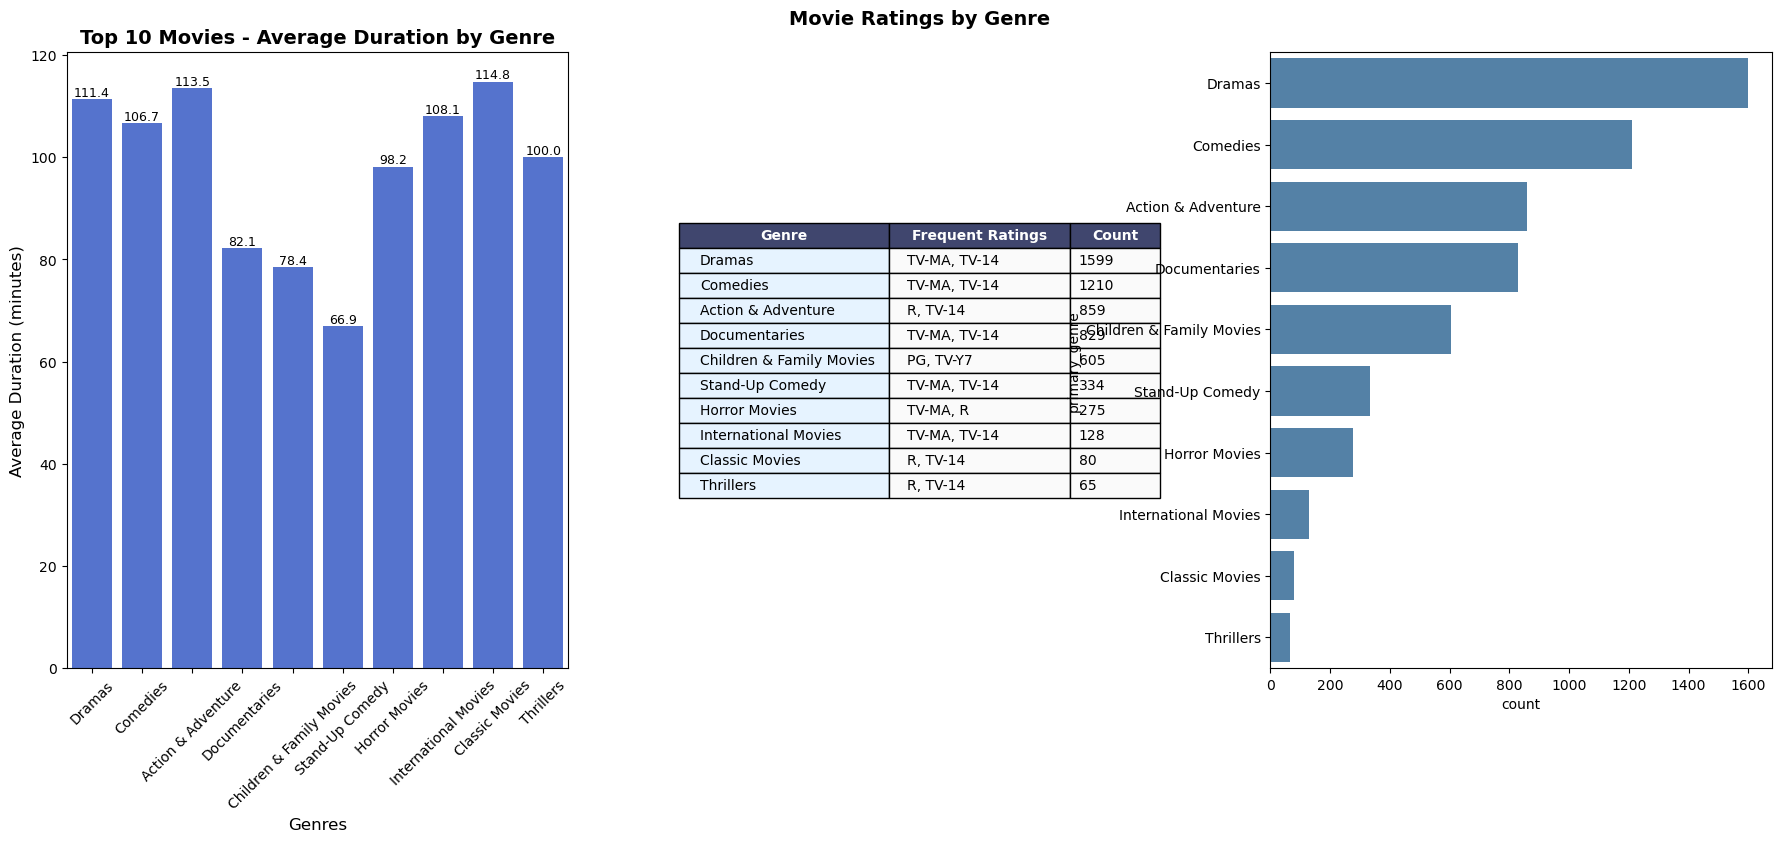

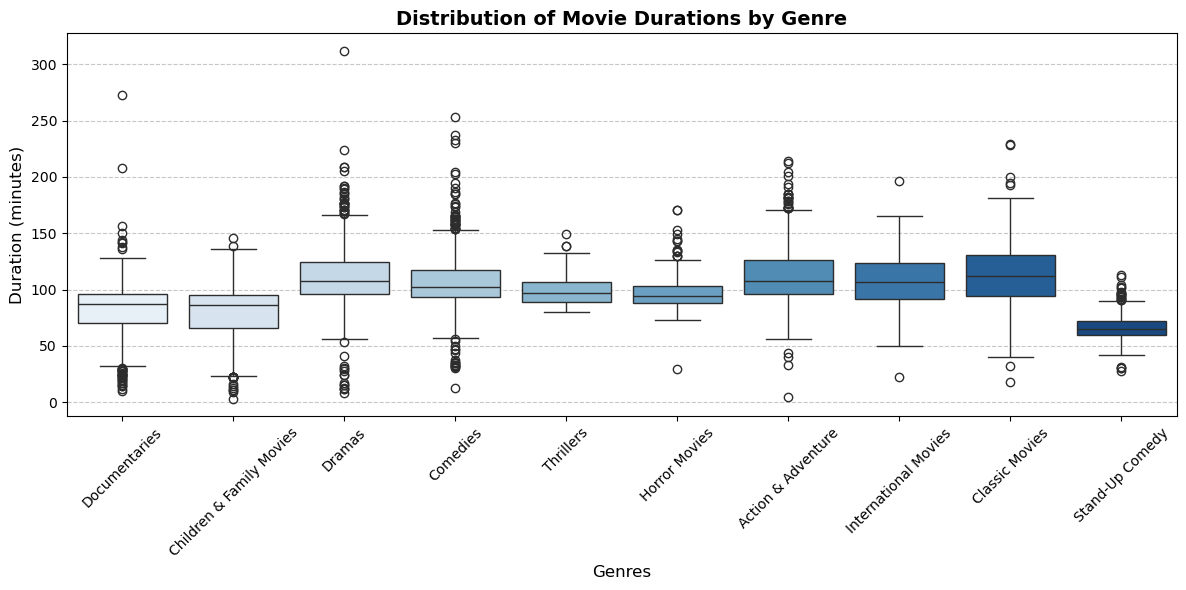

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7620\2885353137.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_genres_count.values, y=top_10_genres_count.index, palette='Blues_r')


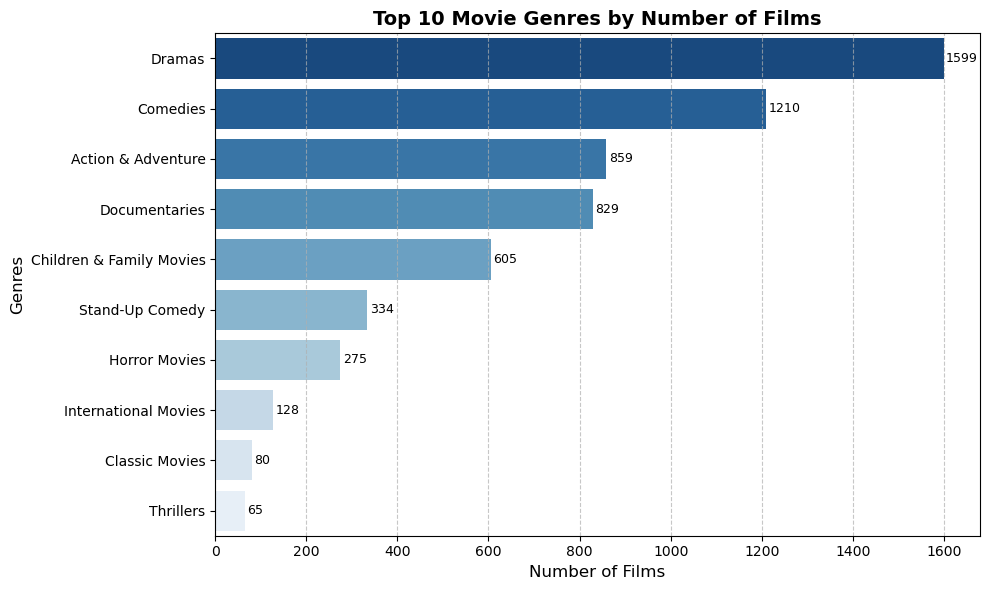

In [217]:
movies_df = df[df['type'] == 'Movie'].copy()
print(f"Number of films: {len(movies_df)}")

movies_df['duration_min'] = movies_df['duration'].str.extract('(\d+)').astype(float)

movies_df['primary_genre'] = movies_df['listed_in'].astype(str).str.split(',').str[0].str.strip()

movies_df = movies_df.dropna(subset=['duration_min', 'primary_genre', 'rating'])
movies_df = movies_df[movies_df['duration_min'] > 0]

movie_stats = movies_df.groupby('primary_genre').agg(
    avg_duration=('duration_min', 'mean'),
    count=('duration_min', 'count'),
    rating_1=('rating', lambda x: x.value_counts().index[0] if len(x.value_counts()) > 0 else 'N/A'),
    rating_2=('rating', lambda x: x.value_counts().index[1] if len(x.value_counts()) > 1 else 'N/A'),
    rating_3=('rating', lambda x: x.value_counts().index[2] if len(x.value_counts()) > 2 else 'N/A')
).reset_index()

movie_stats = movie_stats.sort_values('count', ascending=False).head(10)

print("\n=== TOP 10 GENRES OF FILMS ===")
print(movie_stats[['primary_genre', 'avg_duration', 'count']].to_string(index=False))

fig_movies, axes_movies = plt.subplots(1, 3, figsize=(22, 8))

bars_movies = sns.barplot(data=movie_stats, 
                          x='primary_genre', 
                          y='avg_duration', 
                          color='royalblue',
                          ax=axes_movies[0])

axes_movies[0].set_title('Top 10 Movies - Average Duration by Genre', fontsize=14, fontweight='bold')
axes_movies[0].set_xlabel('Genres', fontsize=12)
axes_movies[0].set_ylabel('Average Duration (minutes)', fontsize=12)
axes_movies[0].tick_params(axis='x', labelrotation=45)

for p in axes_movies[0].patches:
    axes_movies[0].annotate(f'{p.get_height():.1f}', 
                           (p.get_x() + p.get_width() / 2., p.get_height()), 
                           ha='center', va='bottom', fontsize=9)

axes_movies[1].axis('tight')
axes_movies[1].axis('off')

table_data_movies = []
for idx, row in movie_stats.iterrows():
    ratings = [r for r in [row['rating_1'], row['rating_2'], row['rating_3']] if r != 'N/A']
    table_data_movies.append([row['primary_genre'], ', '.join(ratings[:2]), row['count']])

table_movies = axes_movies[1].table(cellText=table_data_movies,
                                   colLabels=['Genre', 'Frequent Ratings', 'Count'],
                                   cellLoc='left',
                                   loc='center',
                                   colWidths=[0.35, 0.3, 0.15])

table_movies.auto_set_font_size(False)
table_movies.set_fontsize(10)
table_movies.scale(1.2, 1.5)

for (i, j), cell in table_movies.get_celld().items():
    if i == 0:  
        cell.set_facecolor('#40466e')
        cell.set_text_props(weight='bold', color='white')
    elif j == 0:  
        cell.set_facecolor('#e6f3ff')
    else:
        cell.set_facecolor('#fafafa')

axes_movies[1].set_title('Movie Ratings by Genre', fontsize=14, pad=20, fontweight='bold')

bars_count = sns.barplot(data=movie_stats, 
                         y='primary_genre',  
                         x='count',         
                         color='steelblue',
                         ax=axes_movies[2])



plt.figure(figsize=(12, 6))
top_genres = movie_stats['primary_genre'].tolist()

top_genres_movies = movies_df[movies_df['primary_genre'].isin(top_genres)]

sns.boxplot(data=top_genres_movies, x='primary_genre', y='duration_min', palette='Blues')
plt.title('Distribution of Movie Durations by Genre', fontsize=14, fontweight='bold')
plt.xlabel('Genres', fontsize=12)
plt.ylabel('Duration (minutes)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
top_10_genres_count = movies_df['primary_genre'].value_counts().head(10)

sns.barplot(x=top_10_genres_count.values, y=top_10_genres_count.index, palette='Blues_r')
plt.title('Top 10 Movie Genres by Number of Films', fontsize=14, fontweight='bold')
plt.xlabel('Number of Films', fontsize=12)
plt.ylabel('Genres', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for i, v in enumerate(top_10_genres_count.values):
    plt.text(v + 5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

Number of TV Series: 2676

=== TOP 10 GENRES OF TV SERIES  ===
         primary_genre  avg_duration  count
International TV Shows      1.339793    774
        Crime TV Shows      1.706767    399
              Kids' TV      1.989664    387
      British TV Shows      1.818182    253
            Docuseries      1.366516    221
          Anime Series      1.577143    175
            Reality TV      1.491667    120
           TV Comedies      3.025000    120
             TV Dramas      2.865672     67
 TV Action & Adventure      2.950000     40


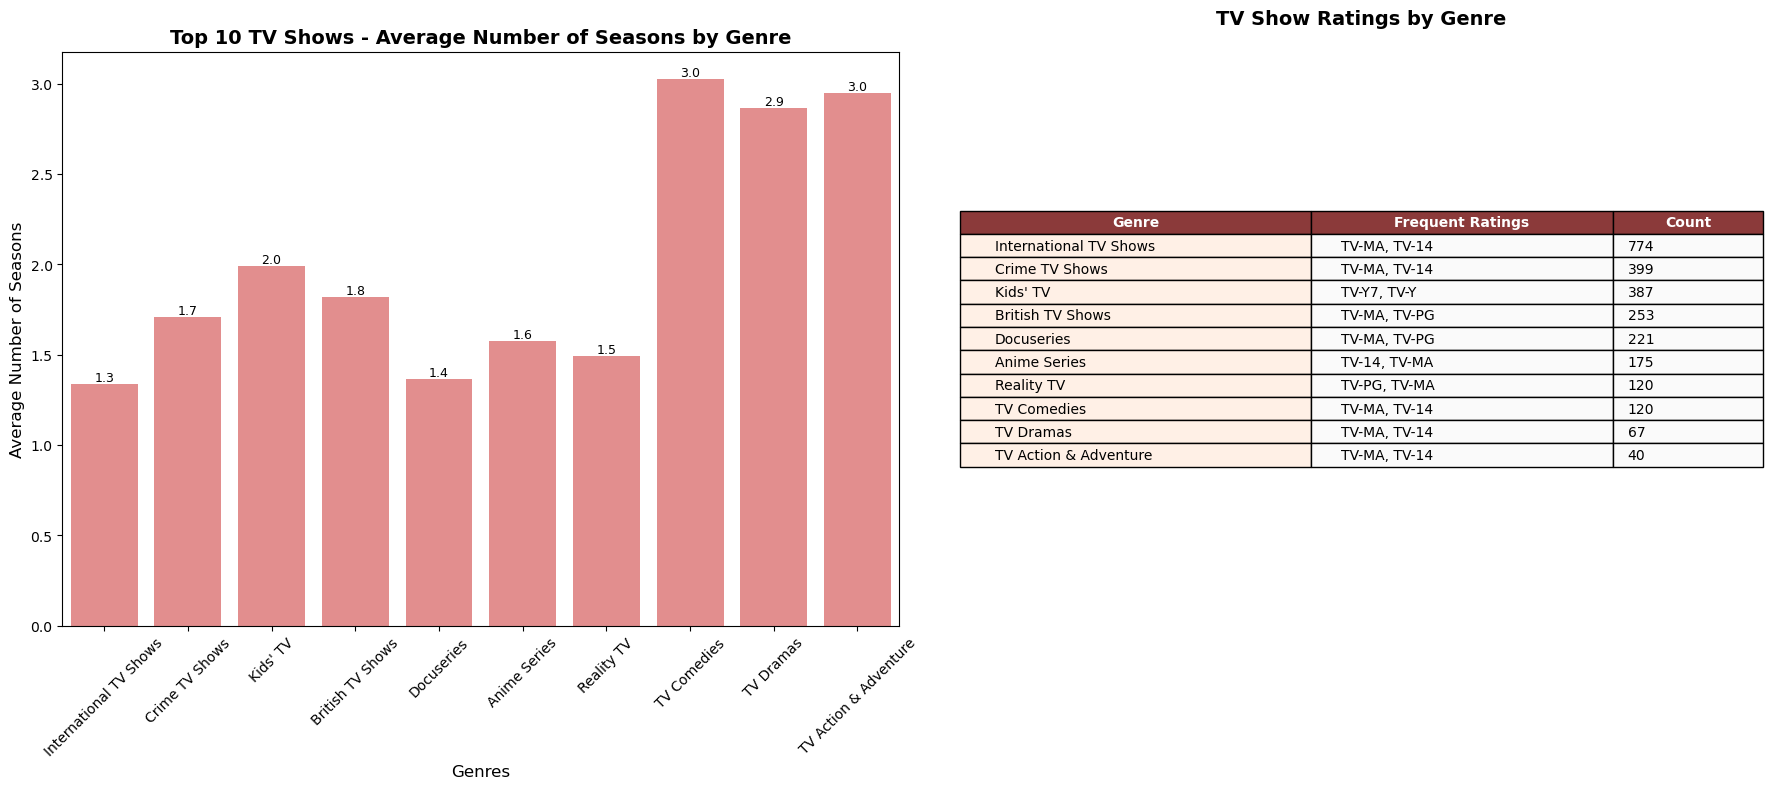

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7620\2858127912.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=top_genres_tv, x='primary_genre', y='nb_seasons', palette='Reds')


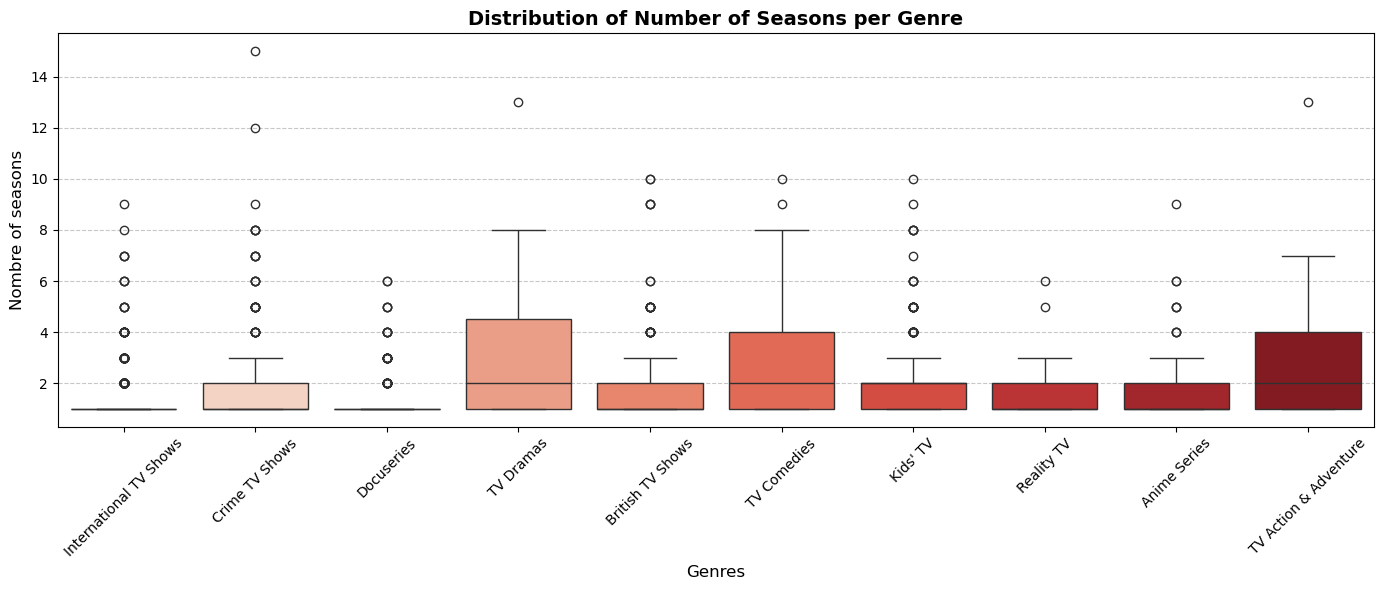

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7620\2858127912.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_genres.values, y=top_10_genres.index, palette='Reds_r')


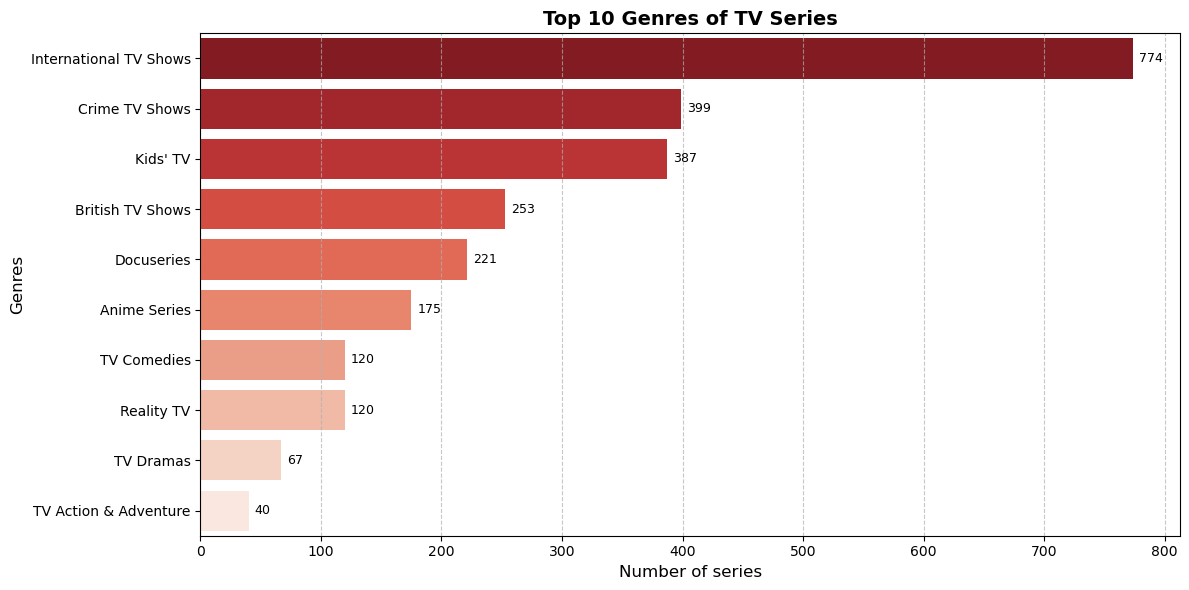

In [214]:
tv_shows_df = df[df['type'] == 'TV Show'].copy()
print(f"Number of TV Series: {len(tv_shows_df)}")

tv_shows_df['nb_seasons'] = tv_shows_df['duration'].str.extract('(\d+)').astype(float)

tv_shows_df['primary_genre'] = tv_shows_df['listed_in'].astype(str).str.split(',').str[0].str.strip()

tv_shows_df = tv_shows_df.dropna(subset=['nb_seasons', 'primary_genre', 'rating'])
tv_shows_df = tv_shows_df[tv_shows_df['nb_seasons'] > 0]



tv_stats = tv_shows_df.groupby('primary_genre').agg(
    avg_seasons=('nb_seasons', 'mean'),  
    count=('nb_seasons', 'count'),        
    rating_1=('rating', lambda x: x.value_counts().index[0] if len(x.value_counts()) > 0 else 'N/A'),
    rating_2=('rating', lambda x: x.value_counts().index[1] if len(x.value_counts()) > 1 else 'N/A'),
    rating_3=('rating', lambda x: x.value_counts().index[2] if len(x.value_counts()) > 2 else 'N/A')
).reset_index()

tv_stats = tv_stats.sort_values('count', ascending=False).head(10)

tv_stats = tv_stats.rename(columns={'avg_seasons': 'avg_duration'})

print("\n=== TOP 10 GENRES OF TV SERIES  ===")
print(tv_stats[['primary_genre', 'avg_duration', 'count']].to_string(index=False))

fig_tv, axes_tv = plt.subplots(1, 2, figsize=(18, 8))

bars_tv = sns.barplot(data=tv_stats, 
                      x='primary_genre', 
                      y='avg_duration', 
                      color='lightcoral',
                      ax=axes_tv[0])

axes_tv[0].set_title('Top 10 TV Shows - Average Number of Seasons by Genre', fontsize=14, fontweight='bold')
axes_tv[0].set_xlabel('Genres', fontsize=12)
axes_tv[0].set_ylabel('Average Number of Seasons', fontsize=12)
axes_tv[0].tick_params(axis='x', labelrotation=45)

for p in axes_tv[0].patches:
    axes_tv[0].annotate(f'{p.get_height():.1f}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='bottom', fontsize=9)

axes_tv[1].axis('tight')
axes_tv[1].axis('off')

table_data_tv = []
for idx, row in tv_stats.iterrows():
    ratings = [r for r in [row['rating_1'], row['rating_2'], row['rating_3']] if r != 'N/A']
    table_data_tv.append([row['primary_genre'], ', '.join(ratings[:2]), row['count']])

table_tv = axes_tv[1].table(cellText=table_data_tv,
                            colLabels=['Genre', 'Frequent Ratings', 'Count'],
                            cellLoc='left',
                            loc='center',
                            colWidths=[0.35, 0.3, 0.15])

table_tv.auto_set_font_size(False)
table_tv.set_fontsize(10)
table_tv.scale(1.2, 1.5)

for (i, j), cell in table_tv.get_celld().items():
    if i == 0: 
        cell.set_facecolor('#8B3A3A')
        cell.set_text_props(weight='bold', color='white')
    elif j == 0:  
        cell.set_facecolor('#fff0e6')
    else:
        cell.set_facecolor('#fafafa')

axes_tv[1].set_title('TV Show Ratings by Genre', fontsize=14, pad=20, fontweight='bold')

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
top_tv_genres = tv_stats['primary_genre'].tolist()

top_genres_tv = tv_shows_df[tv_shows_df['primary_genre'].isin(top_tv_genres)]

sns.boxplot(data=top_genres_tv, x='primary_genre', y='nb_seasons', palette='Reds')
plt.title('Distribution of Number of Seasons per Genre', fontsize=14, fontweight='bold')
plt.xlabel('Genres', fontsize=12)
plt.ylabel('Number of seasons', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
top_10_genres = tv_shows_df['primary_genre'].value_counts().head(10)

sns.barplot(x=top_10_genres.values, y=top_10_genres.index, palette='Reds_r')
plt.title('Top 10 Genres of TV Series', fontsize=14, fontweight='bold')
plt.xlabel('Number of series', fontsize=12)
plt.ylabel('Genres', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for i, v in enumerate(top_10_genres.values):
    plt.text(v + 5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Strategic Content Recommendations for Netflix

Based on the exploratory data analysis of the Netflix dataset, several strategic insights can be derived to help Netflix improve its content catalog and better meet audience preferences.

The analysis focuses on key variables such as **genres (listed_in)**, **countries**, **ratings**, **content types**, and **release years**. By examining the distribution and frequency of these features, we can identify dominant trends, growth opportunities, and underrepresented areas in the catalog.

The following recommendations aim to support **content acquisition and production strategies** for Netflix by:

- Identifying **dominant genres** that drive the majority of the catalog.
- Highlighting **medium-growth categories** that show strong potential for expansion.
- Detecting **less represented genres** that could improve catalog diversity.
- Understanding **global production trends** and **target audiences**.

These insights can help Netflix optimize its **content investment strategy**, maintain audience engagement, and expand its global reach.

In [187]:
print("STRATEGIC CONTENT RECOMMENDATIONS FOR NETFLIX\n")

print("1. Invest more in dominant genres:")
print(top_genres_indiv.head(3))

print("\n2. Maintain growth in medium genres:")
print(top_genres_indiv.iloc[3:6])

print("\n3. Improve diversity by adding titles in rare genres:")
print(underrepresented_genres)

STRATEGIC CONTENT RECOMMENDATIONS FOR NETFLIX

1. Invest more in dominant genres:
listed_in
International Movies    2752
Dramas                  2427
Comedies                1674
Name: count, dtype: int64

2. Maintain growth in medium genres:
listed_in
International TV Shows    1351
Documentaries              869
Action & Adventure         859
Name: count, dtype: int64

3. Improve diversity by adding titles in rare genres:
listed_in
Action & Adventure          859
TV Dramas                   763
Independent Movies          756
Children & Family Movies    641
Romantic Movies             616
Name: count, dtype: int64


In [185]:
countries = df['country'].str.split(', ').explode().value_counts()

print("GLOBAL MARKET RECOMMENDATIONS\n")

print("1. Focus on major production countries:")
print(countries.head(5))

print("\n2. Expand production in emerging markets:")
print(countries.iloc[5:10])

GLOBAL MARKET RECOMMENDATIONS

1. Focus on major production countries:
country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Name: count, dtype: int64

2. Expand production in emerging markets:
country
Japan          318
Spain          232
South Korea    231
Germany        226
Mexico         169
Name: count, dtype: int64


In [184]:
rating_counts = df['rating'].value_counts()

print("AUDIENCE TARGETING RECOMMENDATIONS\n")

print("1. Maintain strong adult content:")
print(rating_counts.head(3))

print("\n2. Increase family-friendly content:")
print(rating_counts.tail(3))

AUDIENCE TARGETING RECOMMENDATIONS

1. Maintain strong adult content:
rating
TV-MA    3207
TV-14    2160
TV-PG     863
Name: count, dtype: int64

2. Increase family-friendly content:
rating
74 min    1
84 min    1
66 min    1
Name: count, dtype: int64


In [183]:
type_counts = df['type'].value_counts()

print("CONTENT FORMAT STRATEGY\n")

print("Current distribution:")
print(type_counts)

print("\nRecommendation:")
print("Increase the proportion of TV Shows to improve user retention.")

CONTENT FORMAT STRATEGY

Current distribution:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Recommendation:
Increase the proportion of TV Shows to improve user retention.


In [182]:
recent_years = df['release_year'].value_counts().sort_index().tail(5)

print("PRODUCTION TREND RECOMMENDATIONS\n")

print("Recent production trend:")
print(recent_years)

print("\nRecommendation:")
print("Focus on producing more recent and modern content to follow viewer demand.")

PRODUCTION TREND RECOMMENDATIONS

Recent production trend:
release_year
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

Recommendation:
Focus on producing more recent and modern content to follow viewer demand.
